In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('AB_NYC_2019.csv')
print(df.shape)
print(df.columns.tolist())
df.info()
df.head(5)

(48895, 16)
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
na = df.isnull().sum()
na[na > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

In [4]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [5]:
print((df['minimum_nights'] >= 365).sum())
print((df['price'] == 0).sum())
print((df['availability_365'] == 0).sum())

43
11
17533


# Sanity

### Price ranges from $0 to $10,000.

### Counted before any drop: price == 0 → 11; minimum_nights ≥ 365 → 43; availability_365 == 0 → 17,533 (~36% of listings).

### Decision: keep all rows for now. Zero price and extreme min-nights are rare; zero availability is common and needs a separate story, not a silent drop.

# KPI's

In [6]:
n = len(df)
mean_price = df['price'].mean()
median_price = df['price'].median()
room_type = (df['room_type'] == 'Entire home/apt').mean()
median_reviews = df['number_of_reviews'].median()
median_availability = df['availability_365'].median()

print(n, mean_price, median_price, room_type, median_reviews, median_availability)

48895 152.7206871868289 106.0 0.5196645873811229 5.0 45.0


# Univariation price histogram
### Most listing prices are within the $0-$400 price range

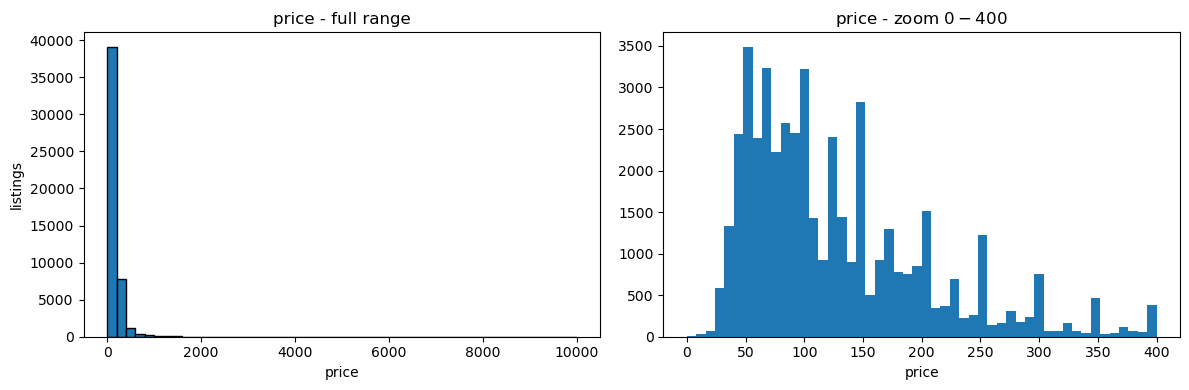

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['price'], bins=50, edgecolor='black')
ax[0].set_title('price - full range')
ax[0].set_xlabel('price')
ax[0].set_ylabel('listings')

ax[1].hist(df['price'], bins=50, range=(0, 400))
ax[1].set_title('price - zoom $0-$400')
ax[1].set_xlabel('price')

plt.tight_layout()
plt.show()

In [8]:
df.groupby(['neighbourhood_group', 'room_type'])['price'].agg(
    ['count', 'mean', 'median']
)

count        mean  median
neighbourhood_group room_type                                 
Bronx               Entire home/apt    379  127.506596   100.0
                    Private room       652   66.788344    53.5
                    Shared room         60   59.800000    40.0
Brooklyn            Entire home/apt   9559  178.327545   145.0
                    Private room     10132   76.500099    65.0
                    Shared room        413   50.527845    36.0
Manhattan           Entire home/apt  13199  249.239109   191.0
                    Private room      7982  116.776622    90.0
                    Shared room        480   88.977083    69.0
Queens              Entire home/apt   2096  147.050573   120.0
                    Private room      3372   71.762456    60.0
                    Shared room        198   69.020202    37.0
Staten Island       Entire home/apt    176  173.846591   100.0
                    Private room       188   62.292553    50.0
                    Shared room          9   57.444444    30.0

### The borough × room-type cell to treat as “expensive typical” is Manhattan Entire (median ~$191, large n). Staten Island Entire’s high mean is a luxury-tail story (median ~$100). Always check mean vs median before calling a cell expensive.

In [10]:
entire = df[df["room_type"] == "Entire home/apt"]

entire.groupby("neighbourhood_group")["price"].agg(["count", "mean", "median"])

,count,mean,median
neighbourhood_group,,,
Bronx,379,127.506596,100.0
Brooklyn,9559,178.327545,145.0
Manhattan,13199,249.239109,191.0
Queens,2096,147.050573,120.0
Staten Island,176,173.846591,100.0


            count        mean  median
review_bin                           
0           10052  192.919021   120.0
1–5         14841  148.499427   101.0
6–20        10753  145.634428   109.0
21–50        6290  137.121304   100.0
50+          6959  128.707573   100.0


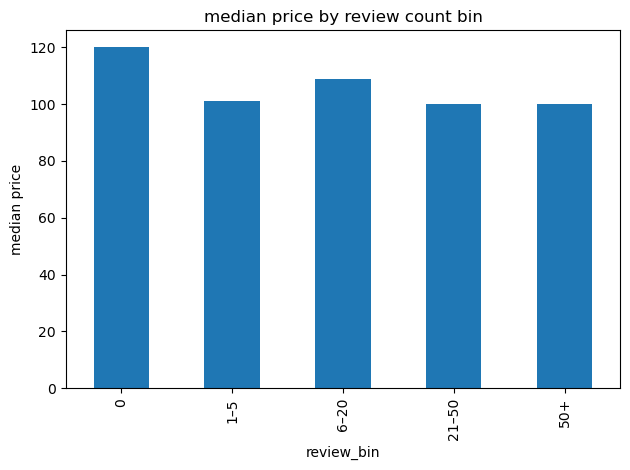

In [11]:
df["review_bin"] = pd.cut(
    df["number_of_reviews"],
    bins=[-0.1, 0, 5, 20, 50, df["number_of_reviews"].max()],
    labels=["0", "1–5", "6–20", "21–50", "50+"],
)
review_price = df.groupby("review_bin", observed=True)["price"].agg(["count", "mean", "median"])
print(review_price)
review_price["median"].plot(kind="bar")
plt.ylabel("median price")
plt.title("median price by review count bin")
plt.tight_layout()
plt.show()

           count        mean  median
avail_bin                           
0          17533  136.032111   100.0
1–90       11713  142.185947   100.0
91–180      5285  161.435951   110.0
181–270     4513  173.415466   125.0
271–365     9851  180.792813   120.0


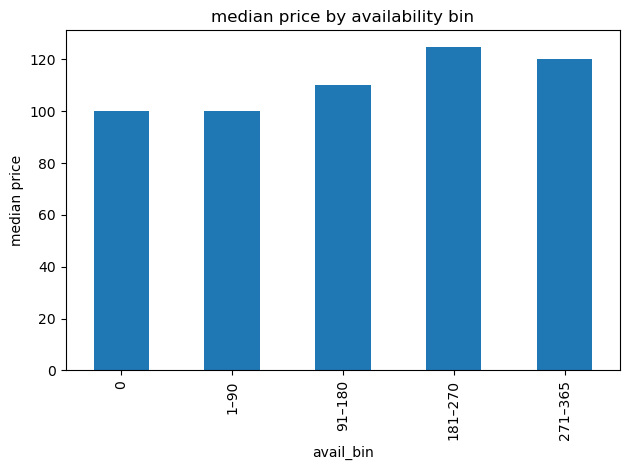

In [12]:
df["avail_bin"] = pd.cut(
    df["availability_365"],
    bins=[-0.1, 0, 90, 180, 270, 365],
    labels=["0", "1–90", "91–180", "181–270", "271–365"],
)

avail_price = df.groupby("avail_bin", observed=True)["price"].agg(["count", "mean", "median"])
print(avail_price)

avail_price["median"].plot(kind="bar")
plt.ylabel("median price")
plt.title("median price by availability bin")
plt.tight_layout()
plt.show()

               count        mean  median
min_night_bin                           
1              12720  142.022877    90.0
2–3            19695  151.948515   118.0
4–7             9147  156.163332   120.0
8–30            6586  161.139387   120.0
31–365           733  240.798090   120.0
365+              14  137.571429   112.5


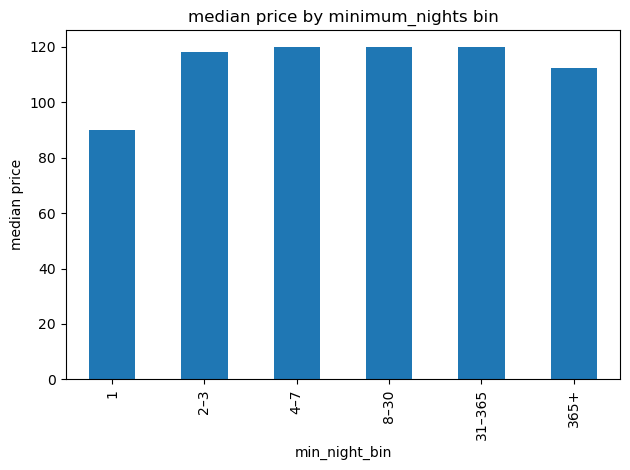

In [15]:
df["min_night_bin"] = pd.cut(
    df["minimum_nights"],
    bins=[0, 1, 3, 7, 30, 365, df["minimum_nights"].max()],
    labels=["1", "2–3", "4–7", "8–30", "31–365", "365+"],
    include_lowest=True,
)

min_price = df.groupby("min_night_bin", observed=True)["price"].agg(["count", "mean", "median"])
print(min_price)

min_price["median"].plot(kind="bar")
plt.ylabel("median price")
plt.title("median price by minimum_nights bin")
plt.tight_layout()
plt.show()

In [23]:
P = 799

capped = df["price"].clip(upper=P)
print("raw mean/median:", df["price"].mean(), df["price"].median())
print("capped mean/median:", capped.mean(), capped.median())
print("listings above cap:", (df["price"] > P).sum())

raw mean/median: 152.7206871868289 106.0
capped mean/median: 143.95623274363433 106.0
listings above cap: 474


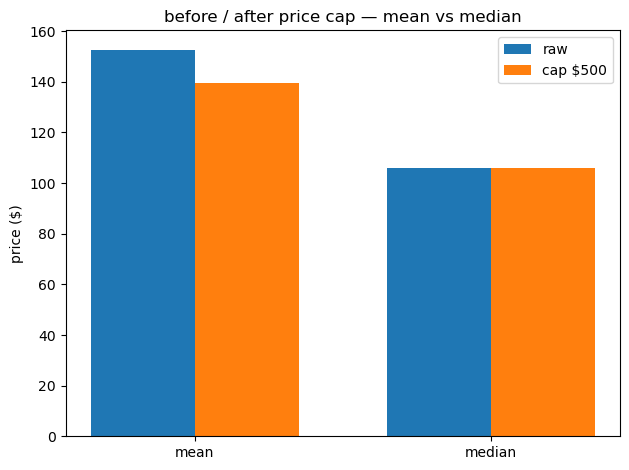

In [25]:
import numpy as np

P = 500
capped = df["price"].clip(upper=P)
labels = ["mean", "median"]
raw_vals = [df["price"].mean(), df["price"].median()]
cap_vals = [capped.mean(), capped.median()]

x = np.arange(len(labels))
w = 0.35
plt.bar(x - w/2, raw_vals, w, label="raw")
plt.bar(x + w/2, cap_vals, w, label=f"cap ${P}")
plt.xticks(x, labels)
plt.ylabel("price ($)")
plt.title("before / after price cap — mean vs median")
plt.legend()
plt.tight_layout()
plt.show()